# Notebook 05 — ResNet-18 Fine-tuning

**Architektur:** ResNet-18 (pretrained auf ImageNet) mit ersetzer FC-Schicht.

**Two-Phase Training** — methodisch begründet:
- Phase 1: Backbone eingefroren, nur FC trainieren (LR=1e-3, 5 Epochs)  
  → verhindert, dass zufällig initialisierter FC-Layer die pretrained Features zerstört
- Phase 2: Alle Layer trainierbar (LR=1e-4, bis zu 35 Epochs, Early Stopping)

**Warum ResNet-18 bei ~2 500 Bildern?**  
Transfer Learning ist bei kleinen Datensätzen überlegen: ImageNet-Features  
(Textur, Form, Farbe) sind generalisierbar. Direkter Vergleich mit Scratch CNN  
dokumentiert den Mehrwert von Pretraining quantitativ.

In [17]:
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as tv_models
from torch.utils.data import DataLoader

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from dataset import AlbumCoverDataset, compute_class_weights  # noqa: E402

SPLITS_DIR      = ROOT / "data" / "splits" / "random"
CHECKPOINTS_DIR = ROOT / "data" / "checkpoints"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Reproduzierbarkeit ────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────
device = (
    torch.device("mps")  if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Device: {device}")

Device: mps


## Konfiguration

In [18]:
PHASE1_LR     = 1e-3
PHASE1_EPOCHS = 5
PHASE2_LR     = 1e-4
PHASE2_EPOCHS = 35
ES_PATIENCE   = 7
BATCH_SIZE    = 32

print(f"Phase 1: lr={PHASE1_LR:.0e}, {PHASE1_EPOCHS} Epochs (FC only)")
print(f"Phase 2: lr={PHASE2_LR:.0e}, max {PHASE2_EPOCHS} Epochs (all layers), patience={ES_PATIENCE}")

Phase 1: lr=1e-03, 5 Epochs (FC only)
Phase 2: lr=1e-04, max 35 Epochs (all layers), patience=7


## DataLoaders & Class Weights

In [19]:
pin         = device.type == "cuda"   # pin_memory nur sinnvoll bei CUDA
num_workers = 0                        # 0 = sicher in Notebooks auf macOS (MPS/fork quirks)

train_loader = DataLoader(
    AlbumCoverDataset(SPLITS_DIR / "train.csv", "train"),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=num_workers, pin_memory=pin,
)
val_loader = DataLoader(
    AlbumCoverDataset(SPLITS_DIR / "val.csv", "val"),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=pin,
)

class_weights = compute_class_weights(SPLITS_DIR / "train.csv").to(device)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 56, Val batches: 12


## Modell — ResNet-18 mit ersetztem FC

In [20]:
model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 10)  # in_features = 512
model = model.to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_start = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameter gesamt: {total_params:,}")
print(f"Trainierbar (Phase 1 start): {model.fc.weight.numel() + model.fc.bias.numel():,}  (nur FC)")

Parameter gesamt: 11,181,642
Trainierbar (Phase 1 start): 5,130  (nur FC)


## Hilfsfunktion: eine Trainings-Epoch

In [21]:
criterion = nn.CrossEntropyLoss(weight=class_weights)


def run_epoch(
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None,
    train: bool,
) -> tuple[float, float]:
    """Führt eine Epoch durch und gibt (loss, accuracy) zurück."""
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.no_grad() if not train else torch.enable_grad()
    with ctx:  # type: ignore[attr-defined]
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            if train and optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += len(labels)
    return total_loss / total, correct / total

## Phase 1 — Backbone eingefroren, nur FC

In [22]:
# Backbone einfrieren
for name, param in model.named_parameters():
    param.requires_grad = name.startswith("fc.")

optimizer_p1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR,
)

history: dict[str, list[float]] = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
}

print("Phase 1: Backbone frozen, FC training")
for epoch in range(1, PHASE1_EPOCHS + 1):
    tl, ta = run_epoch(train_loader, optimizer_p1, train=True)
    vl, va = run_epoch(val_loader,   None,          train=False)
    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["train_acc"].append(ta)
    history["val_acc"].append(va)
    print(f"  Epoch {epoch}/{PHASE1_EPOCHS}  train_loss={tl:.4f} train_acc={ta:.3f}  "
          f"val_loss={vl:.4f} val_acc={va:.3f}")

print("Phase 1 abgeschlossen.")

Phase 1: Backbone frozen, FC training
  Epoch 1/5  train_loss=2.2863 train_acc=0.168  val_loss=2.1236 val_acc=0.238
  Epoch 2/5  train_loss=1.9743 train_acc=0.313  val_loss=2.0255 val_acc=0.277
  Epoch 3/5  train_loss=1.8313 train_acc=0.362  val_loss=1.9697 val_acc=0.306
  Epoch 4/5  train_loss=1.7722 train_acc=0.397  val_loss=2.0013 val_acc=0.312
  Epoch 5/5  train_loss=1.6984 train_acc=0.422  val_loss=1.9199 val_acc=0.314
Phase 1 abgeschlossen.


## Phase 2 — Alle Layer trainierbar, Fine-tuning mit Early Stopping

In [23]:
# Alle Layer auftauen
for param in model.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam(model.parameters(), lr=PHASE2_LR)

best_val_acc    = max(history["val_acc"])  # bereits in Phase 1 erreicht
patience_count  = 0
checkpoint_path = CHECKPOINTS_DIR / "resnet18_best.pt"
start_time      = time.time()

print(f"Phase 2: All layers, lr={PHASE2_LR:.0e}, max {PHASE2_EPOCHS} Epochs")
for epoch in range(1, PHASE2_EPOCHS + 1):
    tl, ta = run_epoch(train_loader, optimizer_p2, train=True)
    vl, va = run_epoch(val_loader,   None,          train=False)
    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["train_acc"].append(ta)
    history["val_acc"].append(va)

    global_epoch = PHASE1_EPOCHS + epoch
    print(f"  Epoch {global_epoch:3d}  train_loss={tl:.4f} train_acc={ta:.3f}  "
          f"val_loss={vl:.4f} val_acc={va:.3f}", end="")

    if va > best_val_acc:
        best_val_acc   = va
        patience_count = 0
        torch.save(
            {"state_dict": model.state_dict(), "epoch": global_epoch, "val_acc": va},
            checkpoint_path,
        )
        print("  ✓ checkpoint")
    else:
        patience_count += 1
        print(f"  (patience {patience_count}/{ES_PATIENCE})")
        if patience_count >= ES_PATIENCE:
            print(f"\nEarly Stopping nach Epoch {global_epoch}.")
            break

train_time = time.time() - start_time
print(f"\nBeste Val-Accuracy: {best_val_acc:.3f}")
print(f"Trainingszeit (Phase 2): {train_time:.0f}s")
print(f"Checkpoint: {checkpoint_path}")

Phase 2: All layers, lr=1e-04, max 35 Epochs
  Epoch   6  train_loss=1.5967 train_acc=0.443  val_loss=1.7679 val_acc=0.387  ✓ checkpoint
  Epoch   7  train_loss=1.0010 train_acc=0.675  val_loss=1.7718 val_acc=0.406  ✓ checkpoint
  Epoch   8  train_loss=0.6710 train_acc=0.830  val_loss=1.8602 val_acc=0.398  (patience 1/7)
  Epoch   9  train_loss=0.4218 train_acc=0.913  val_loss=1.8885 val_acc=0.421  ✓ checkpoint
  Epoch  10  train_loss=0.2453 train_acc=0.966  val_loss=1.9665 val_acc=0.411  (patience 1/7)
  Epoch  11  train_loss=0.1734 train_acc=0.976  val_loss=2.0129 val_acc=0.435  ✓ checkpoint
  Epoch  12  train_loss=0.1134 train_acc=0.989  val_loss=2.0737 val_acc=0.429  (patience 1/7)
  Epoch  13  train_loss=0.0699 train_acc=0.995  val_loss=2.0692 val_acc=0.437  ✓ checkpoint
  Epoch  14  train_loss=0.0562 train_acc=0.994  val_loss=2.1542 val_acc=0.427  (patience 1/7)
  Epoch  15  train_loss=0.0461 train_acc=0.996  val_loss=2.1475 val_acc=0.424  (patience 2/7)
  Epoch  16  train_loss=0

## Loss- und Accuracy-Kurven (beide Phasen)

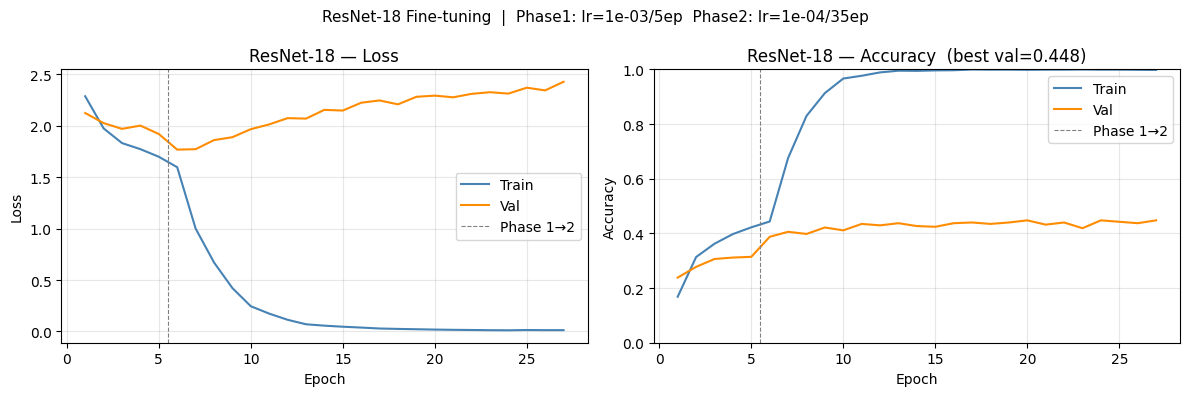

In [24]:
epochs_run = range(1, len(history["train_loss"]) + 1)
phase_boundary = PHASE1_EPOCHS + 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for ax, key_train, key_val, ylabel in [
    (ax1, "train_loss", "val_loss",  "Loss"),
    (ax2, "train_acc",  "val_acc",   "Accuracy"),
]:
    ax.plot(epochs_run, history[key_train], label="Train", color="steelblue")
    ax.plot(epochs_run, history[key_val],   label="Val",   color="darkorange")
    ax.axvline(phase_boundary, color="grey", linestyle="--", linewidth=0.8, label="Phase 1→2")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

ax2.set_ylim(0, 1)
ax1.set_title("ResNet-18 — Loss")
ax2.set_title(f"ResNet-18 — Accuracy  (best val={best_val_acc:.3f})")

plt.suptitle(
    f"ResNet-18 Fine-tuning  |  Phase1: lr={PHASE1_LR:.0e}/{PHASE1_EPOCHS}ep  "
    f"Phase2: lr={PHASE2_LR:.0e}/{PHASE2_EPOCHS}ep",
    fontsize=11,
)
plt.tight_layout()
plt.show()